# Latent Masked Simple Attention (Softmax) Overview

Straightforward demo notebook for the simple `LatentAttnMasked` attention model.

This version keeps the model in the non-Transformer regime and focuses on:
- PCA latent structure
- token construction before and after attention
- intuitive attention heatmaps
- a short math summary and a final markdown export cell


In [20]:
import importlib
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

import main
import models.config
import models.eval
import models.lightning_module
import models.loss
import models.latent_attn_masked
import models.conditional_gaussian

importlib.reload(models.loss)
importlib.reload(models.lightning_module)
importlib.reload(models.latent_attn_masked)
importlib.reload(models.conditional_gaussian)
importlib.reload(models.eval)
importlib.reload(models.config)
importlib.reload(main)

from IPython.display import Markdown, display
from main import Sim
from models.config import build_model
from models.loss import get_model_input

RESULTS_ROOT = Path('results/local_results')
RESULTS_ROOT.mkdir(parents=True, exist_ok=True)


In [21]:
config_override = {
    "model": {
        "n_components_pca": 128,
        "n_components_pls": 64,
        "token_embedding_type": "learned",
        "token_embedding_dim": 32,
        "attn_dim": 64,
        "value_dim": 64,
        "transformer_layers": 0,
        "num_heads": 1,
        "attention_activation": "identity",
        "readout_type": "scalar_slot",
        "readout_hidden_dim": 64,
        "residual_mode": "attention_only",
        "mask_ratio": 0.9,
        "train_use_visible_fc_context": True,
        "sc_token_dropout": 0.0,
        "attention_dropout": 0.0,
        "reg": 1e-7,
    },
    "trainer": {
        "max_epochs": 100,
        "batch_size": 128,
        "lr": 1e-3,
        "loss_type": "mse",
    },
}

sim = Sim(
    model_name="LatentAttnMasked",
    config_overrides=config_override,
    source="SC",
    target="FC",
    parcellation="Glasser",
    shuffle_seed=0,
    data_load_mode="precomputed",
)

/ext3/miniforge3/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/ext3/miniforge3/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


LatentAttnMasked init | src=SC tgt=FC | k=128 pls=64 | token_embedding_type=learned token_embedding_dim=32 | residual_mode=none residual_gain_init=0.001 | attn_dim=64 value_dim=64 | transformer_layers=0 num_heads=1 | readout_type=scalar_slot readout_hidden_dim=64 | attention_activation=softmax | zscore_pca_scores=False | mask_ratio=0.9 visible_fc_context=True | sc_token_dropout=0.0


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
/home/asr655/.local/lib/python3.12/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:881: Checkpoint directory /scratch/asr655/neuroinformatics/Conn2Conn/checkpoints exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name    | Type             | Params | Mode  | FLOPs
-------------------------------------------------------------
0 | model   | LatentAttnMasked | 12.4 K | train | 0    
1 | loss_fn | MSELoss          | 0      | train | 0    
---------

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/home/asr655/.local/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=4` in the `DataLoader` to improve performance.
/home/asr655/.local/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=4` in the `DataLoader` to improve performance.


Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=100` reached.



Training complete!


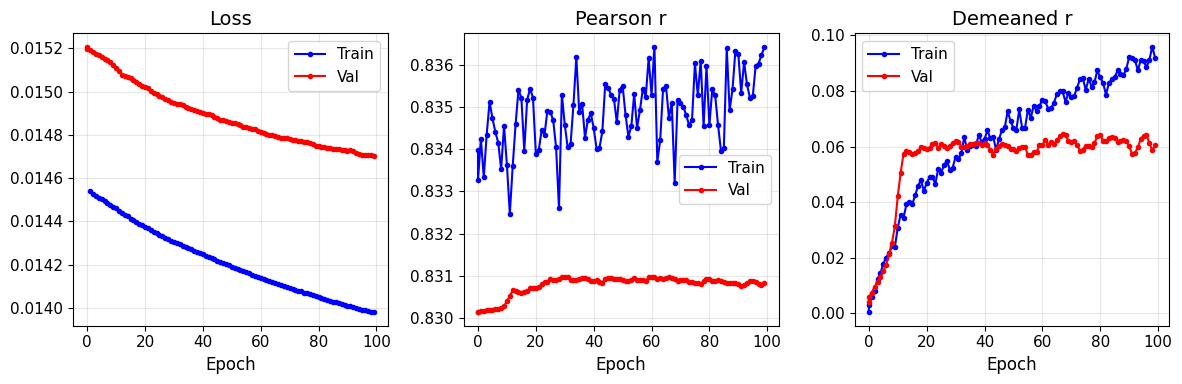

Number of unique demographic categories: 14
Top-1 accuracy: 0.021  (4 of 195 subjects had rank 1) (chance=0.005)
Average rank percentile: 0.551 (chance=0.5)


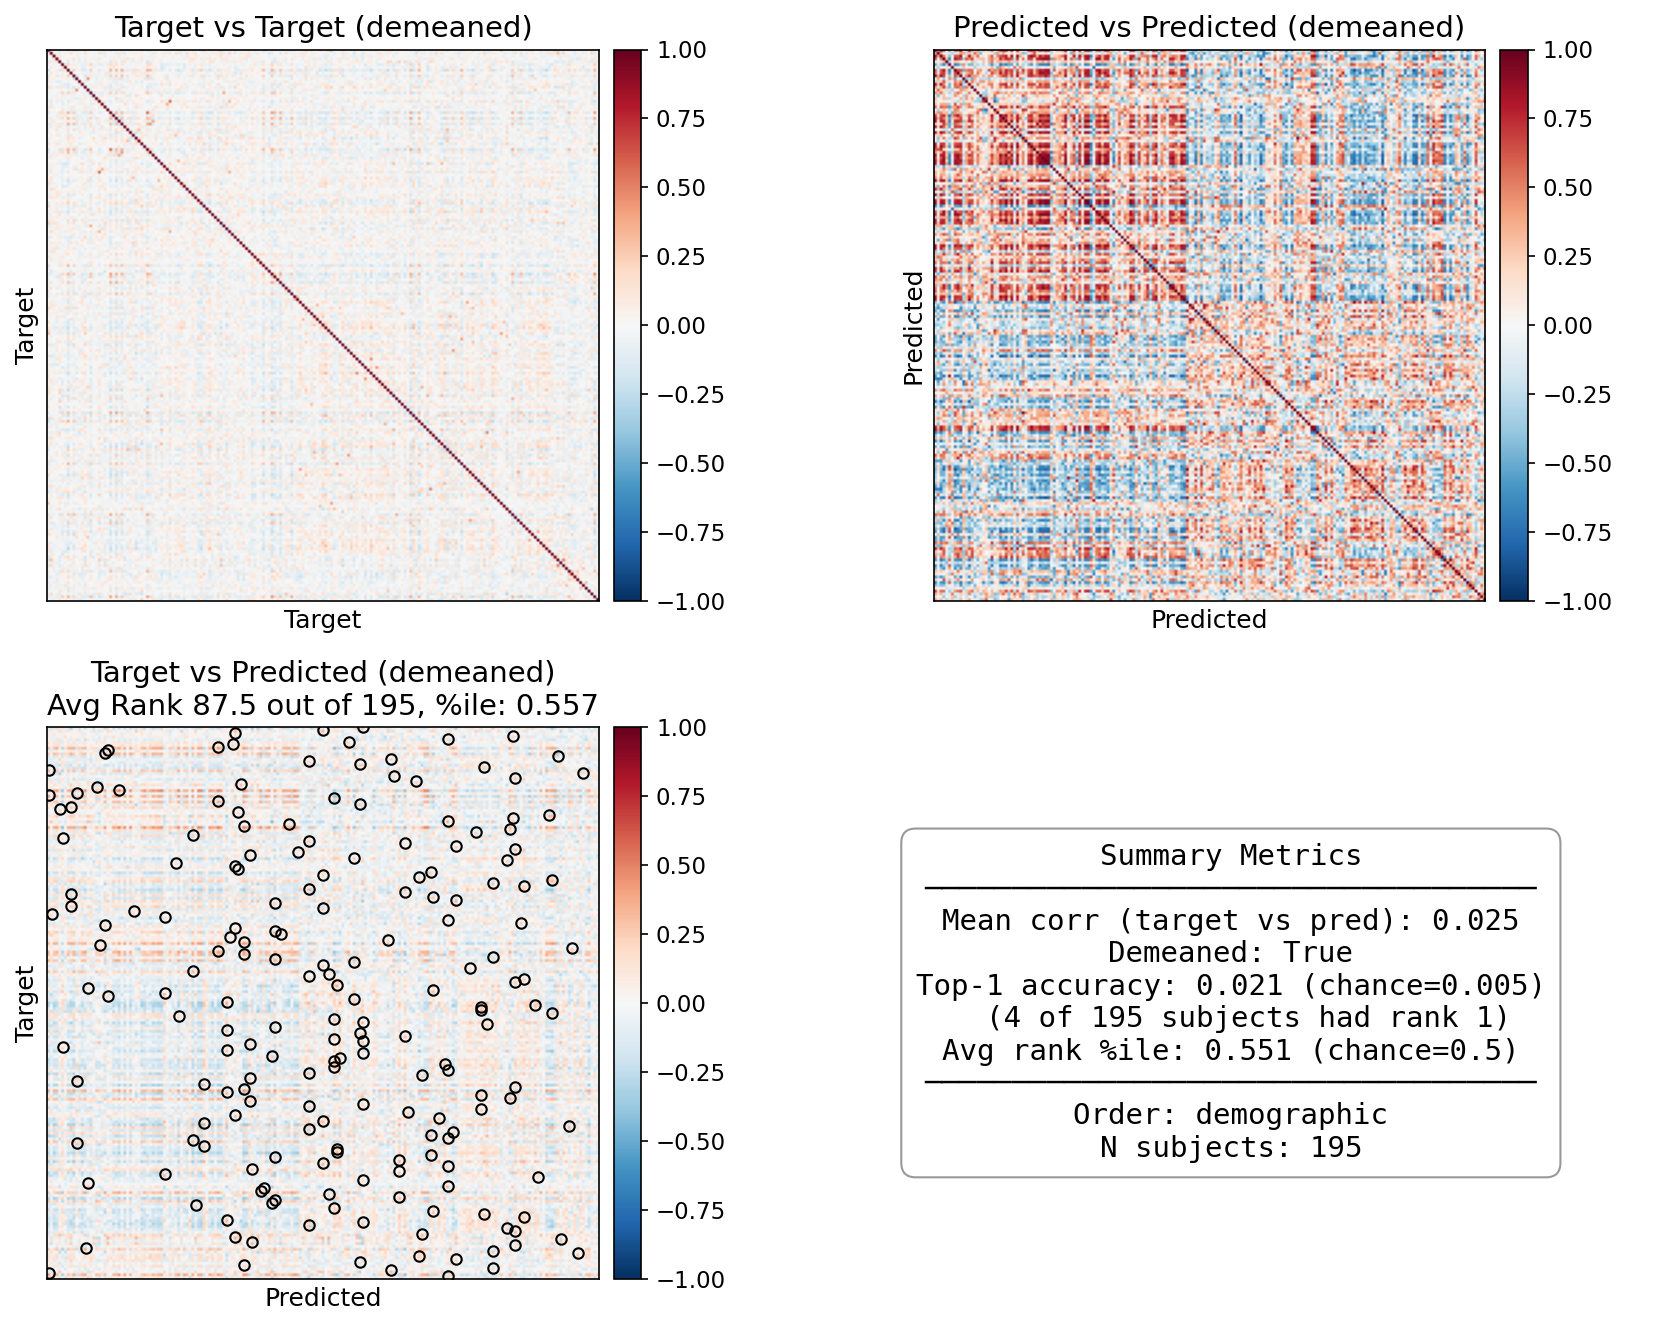

returned noise_preds [[ 0.10335521  0.27345122  0.79338547 ...  0.07845211  0.10779614
   0.35724186]
 [ 0.1919979   0.47149277  0.6724819  ... -0.13729251 -0.09331813
   0.66529665]
 [ 0.3631451   0.63926478  0.88444692 ... -0.01370378  0.1294217
   0.39960487]
 ...
 [-0.08238107  0.82869741  1.07752772 ... -0.06908563 -0.00440757
   0.40327927]
 [ 0.12395491  0.68586381  0.6269891  ... -0.12566293  0.16673286
   0.53747594]
 [ 0.05569953  0.62698837  0.69579952 ... -0.09271121  0.09947315
   0.36341394]]


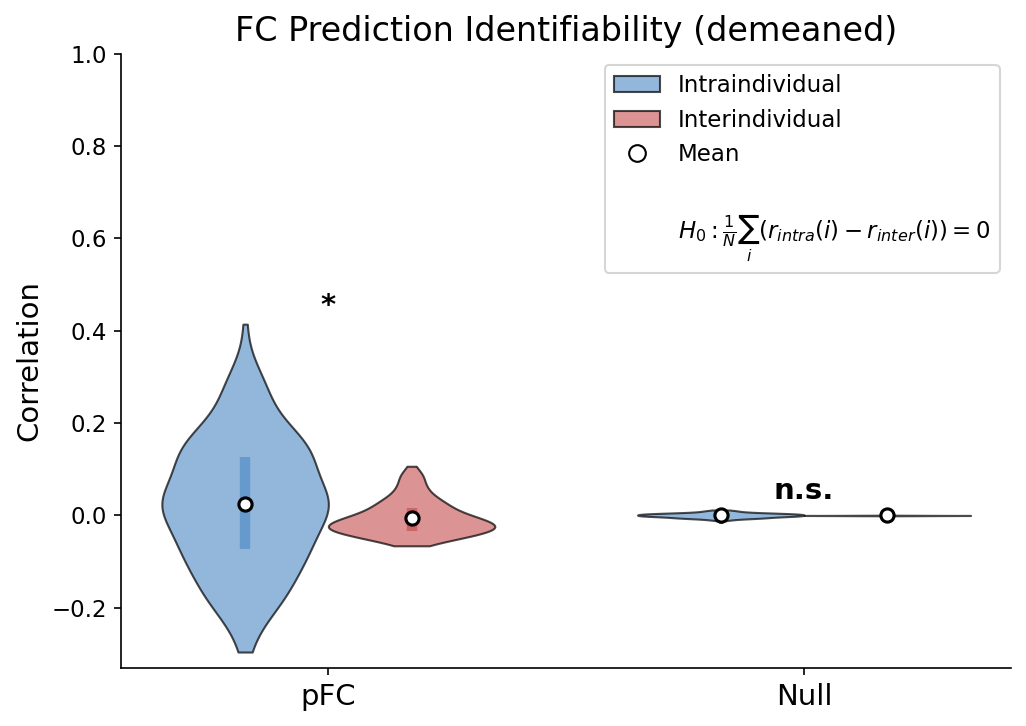


Identifiability Summary:
Condition    r_intra    r_inter    d          t          p            Cohen d   
----------------------------------------------------------------------
pFC          0.0254     -0.0047    0.0301     3.20       1.61e-03     0.23      
Null         0.0004     -0.0001    0.0005     1.35       1.78e-01     0.10      


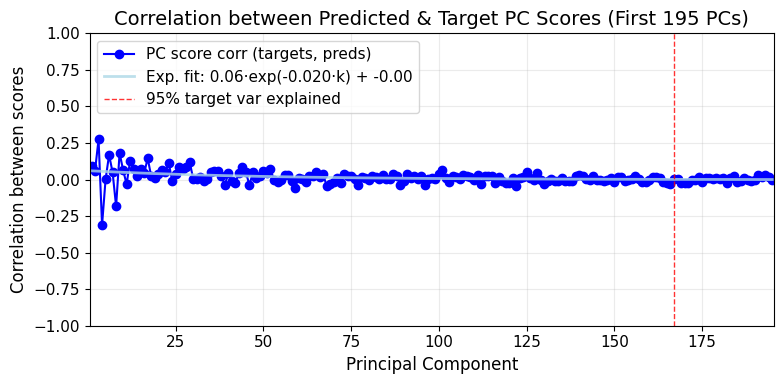

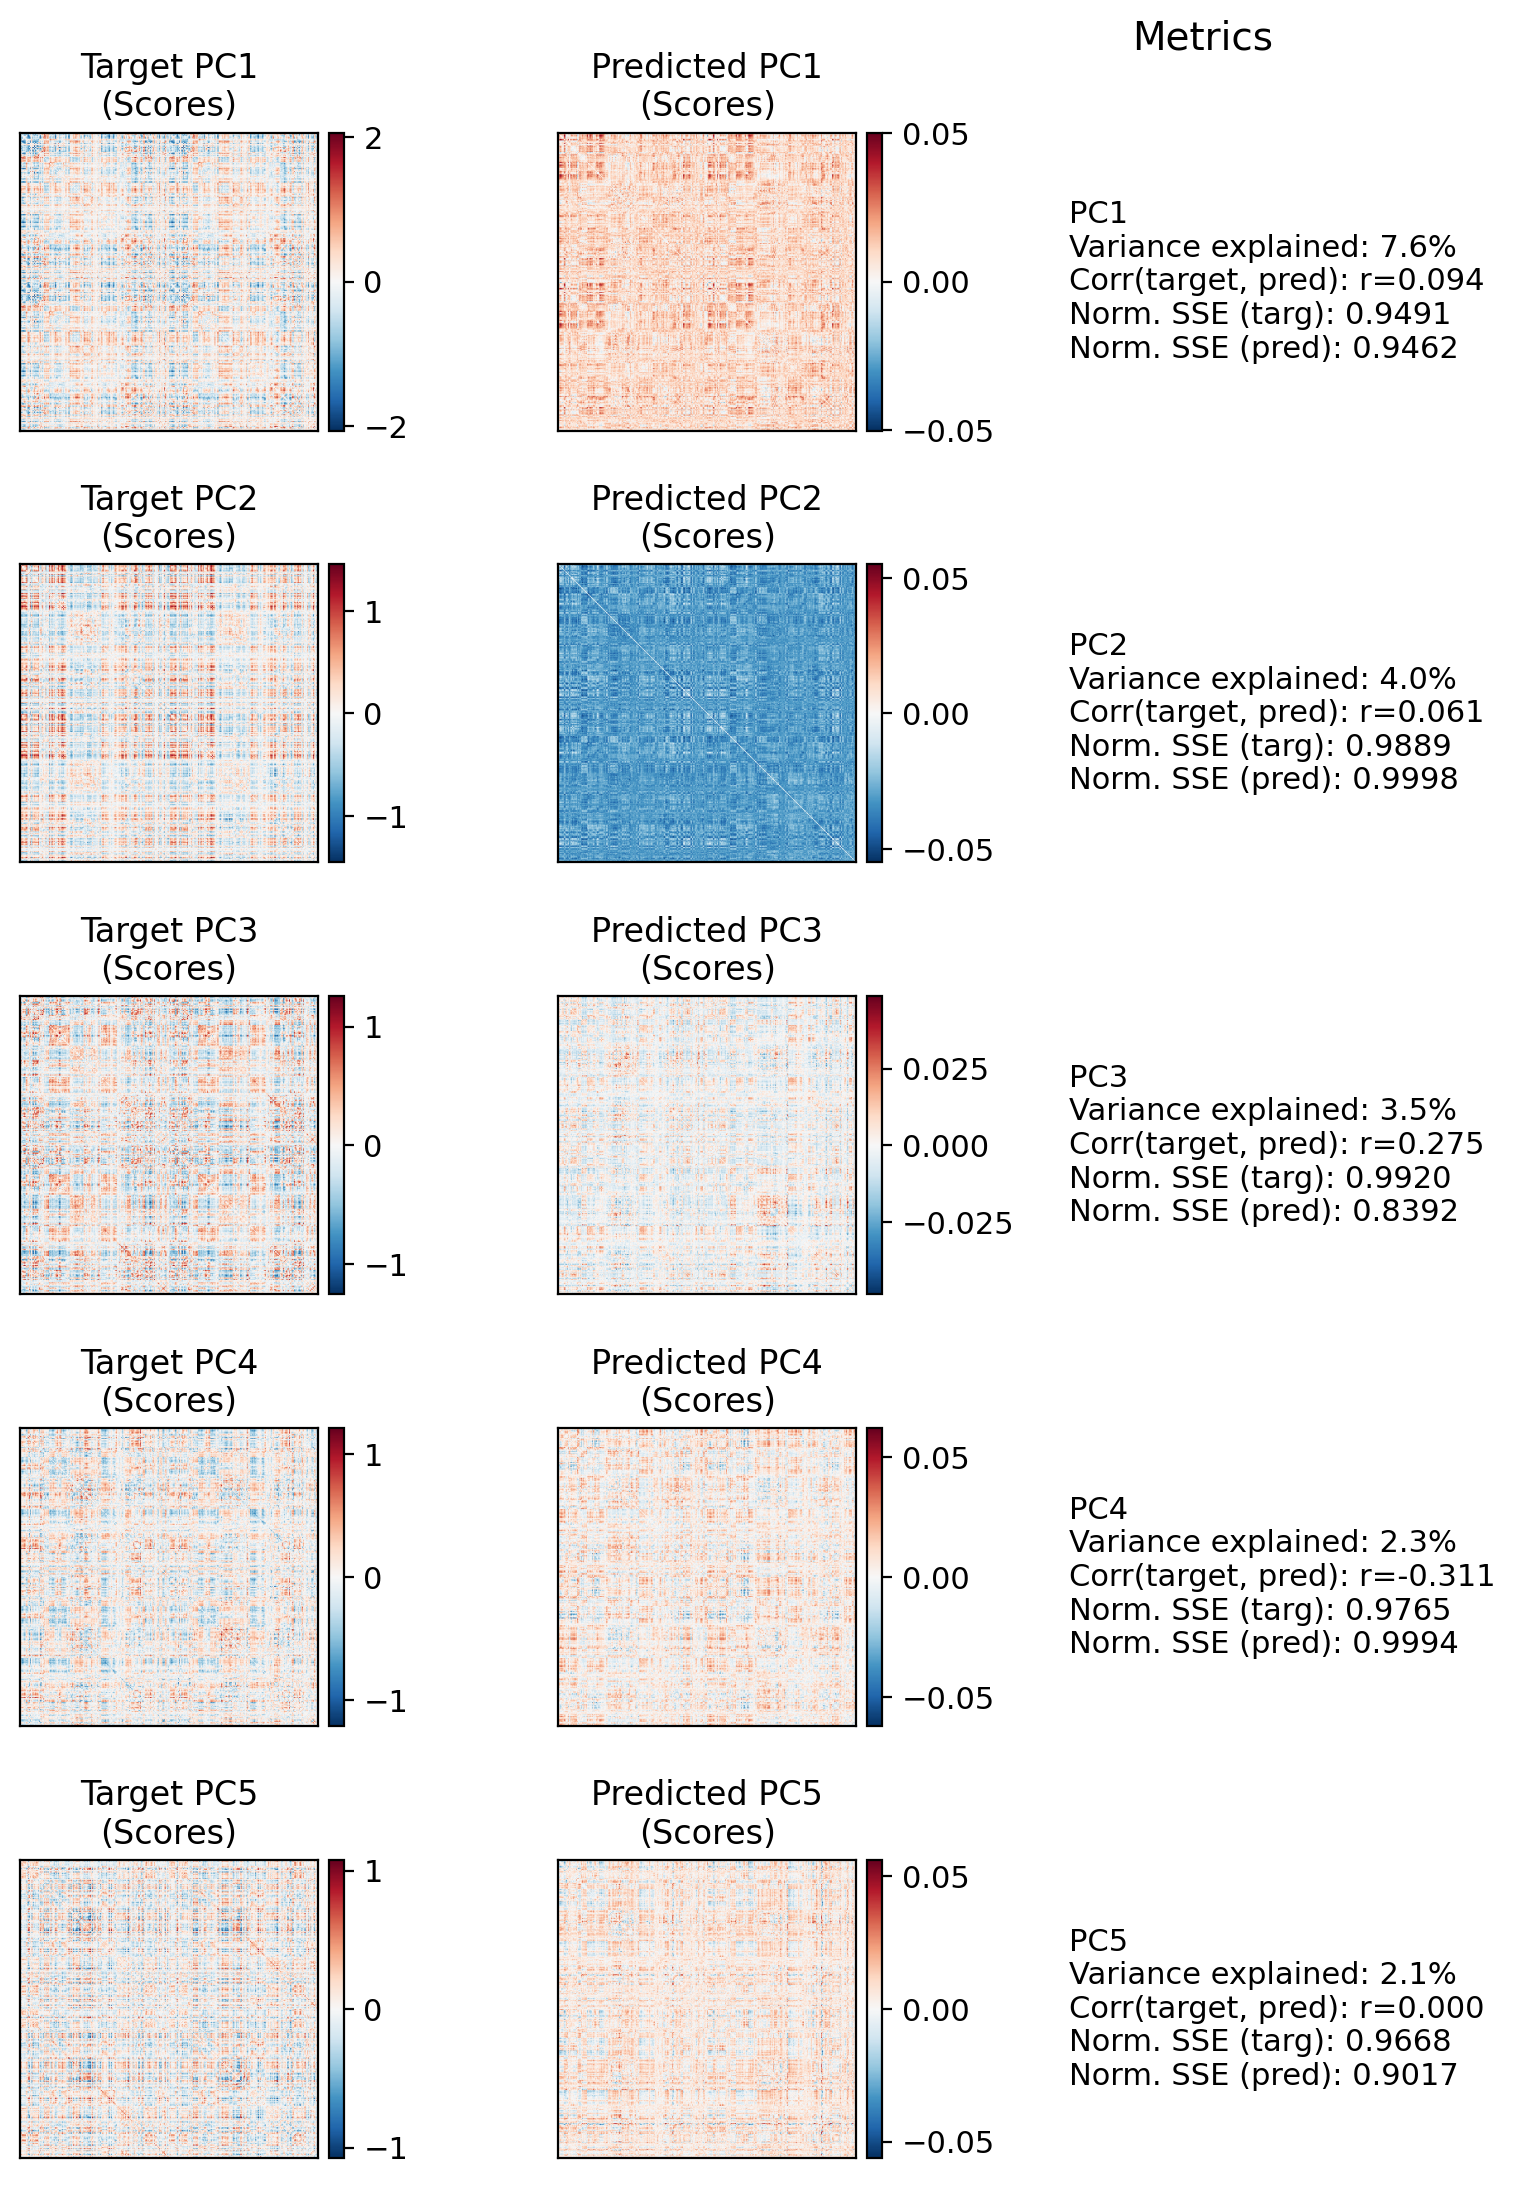

{'mse': np.float32(0.013344258),
 'r2': np.float32(-0.010007487),
 'pearson': np.float32(0.83878547),
 'demeaned_pearson': np.float32(0.025381831),
 'avg_rank': np.float64(0.5627613412228797),
 'top1_acc': np.float64(0.015384615384615385)}

In [22]:
# RANK OF 0.8 

# Small defaults for quick local iteration
config_override = {
    "model": {
        "n_components_pca": 128,
        "token_embedding_type": "learned",  # pls or learned
        "token_embedding_dim": 32,
        "attn_dim": 64,
        "attention_activation": "softmax",  # "identity" or "softmax"
        "readout_type": "scalar_slot", # linear, mlp, concat_mlp, or scalar_slot #
        "value_dim": 64, # no influence when scalar_slot
        "readout_hidden_dim": 64, # no influence when scalar_slot # let's make this deeper soon...
        "residual_mode": "attention_only",   # or "attention_only", "linear_residual"
        "mask_ratio": 0.9,
        "train_use_visible_fc_context": True,
        "sc_token_dropout": 0.0,
        "attention_dropout": 0.0,
        "reg": 1e-7
    },
    "trainer": {
        "max_epochs": 100,
        "batch_size": 128,
        "lr": 1e-3, # 5e-4,
        "loss_type": "mse",
        # "loss_type": "joint_edge_latent_mse_scaled", # mse, latent_mse, or latent_mse_weighted, joint_edge_latent_mse
        # "loss_type": "mse",
        # "loss_latent_weight": 0.01,
        # "loss_var_weight": 0.01,
        # "loss_latent_weight": 0.5,
        # "loss_scale_ema_decay": 0.95,
        # "loss_scale_warmup_steps": 100,
    },
}

run_out = sim._run_learned_single(
    mode="dev",
    save_checkpoint=False,
    config_override=config_override,
    run_eval=True,
)

run_out["test_metrics"]["base_metrics"]


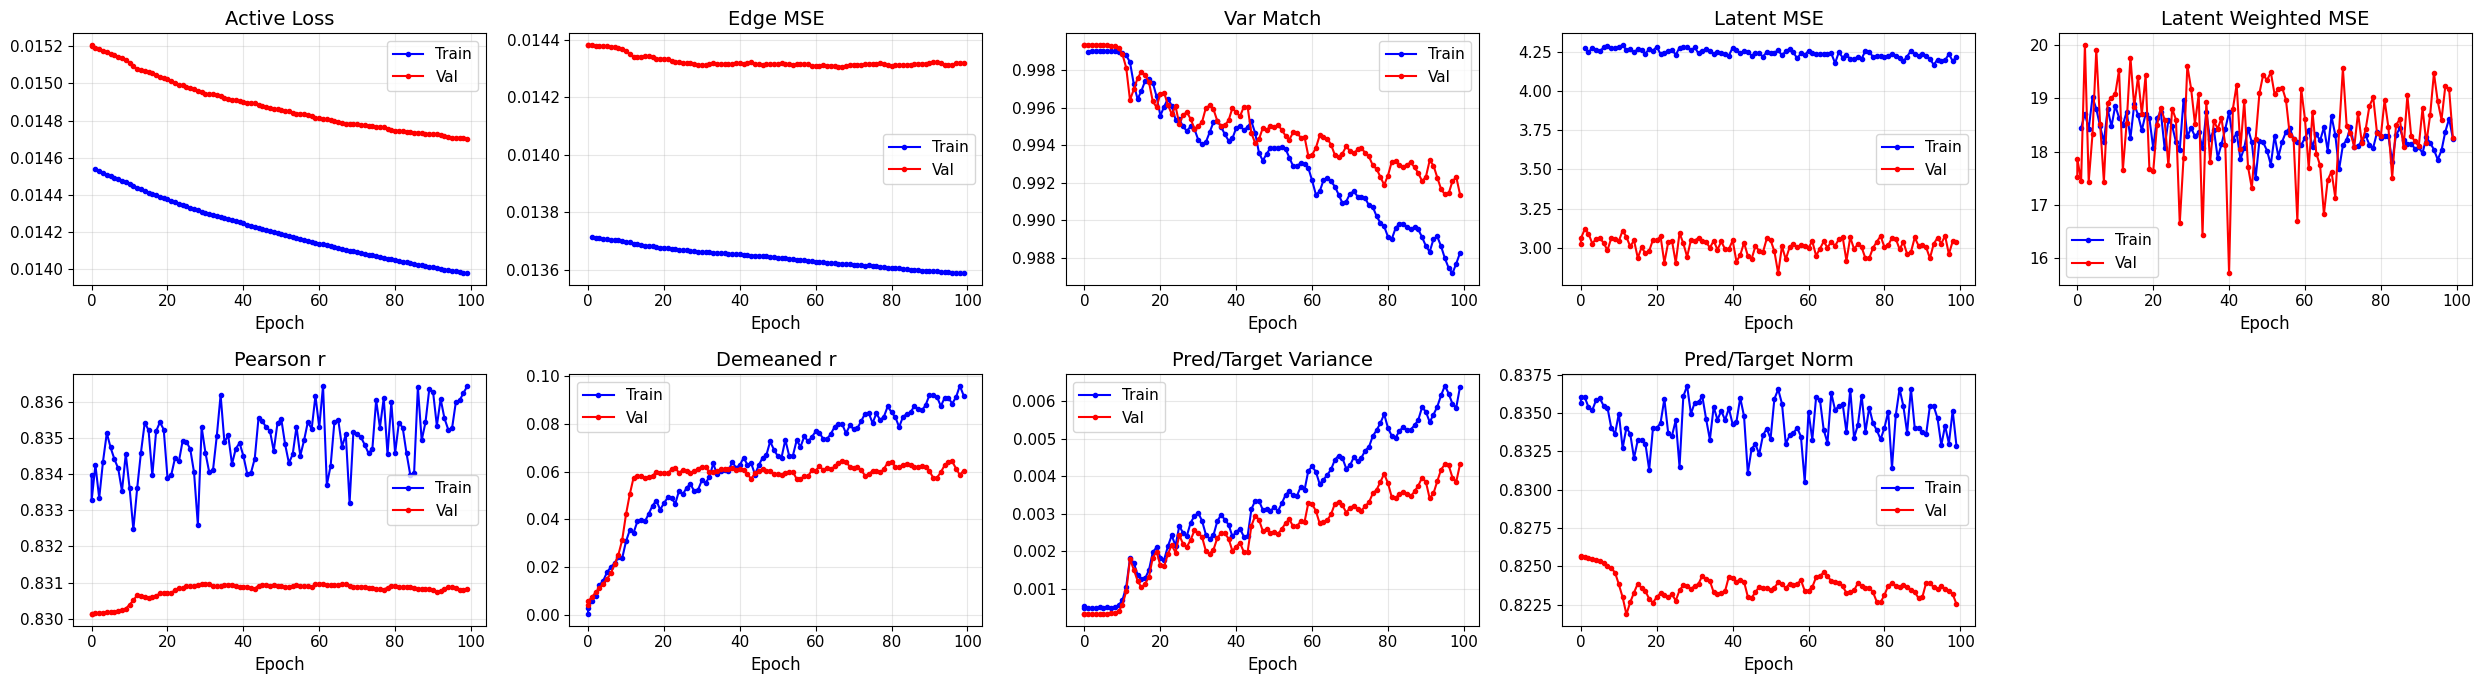

In [23]:
run_out["train_result"].plot(style="latent")

In [24]:
model_trained = run_out["model"]
model_trained.eval()
model_init = build_model(sim.base, "LatentAttnMasked", config_override["model"])
model_init.eval()

val_batch = next(iter(sim.val_loader))
x_val = get_model_input(val_batch)
y_val = val_batch["y"]

x_example = x_val[:1]
y_example = y_val[:1]
x_mean = x_val[:16]
y_mean = y_val[:16]

with torch.no_grad():
    inspect_init = model_init.inspect_attention_state(x_example, y=y_example, force_all_masked=True)
    inspect_trained = model_trained.inspect_attention_state(x_example, y=y_example, force_all_masked=True)
    inspect_mean = model_trained.inspect_attention_state(x_mean, y=y_mean, force_all_masked=True)

sc_scores = model_trained.source_pca_scores_train.detach().cpu().numpy()
fc_scores = model_trained.target_pca_scores_train.detach().cpu().numpy()


LatentAttnMasked init | src=SC tgt=FC | k=128 pls=16 | token_embedding_type=learned token_embedding_dim=32 | residual_mode=none residual_gain_init=0.001 | attn_dim=64 value_dim=64 | transformer_layers=0 num_heads=1 | readout_type=scalar_slot readout_hidden_dim=64 | attention_activation=softmax | zscore_pca_scores=False | mask_ratio=0.9 visible_fc_context=True | sc_token_dropout=0.0


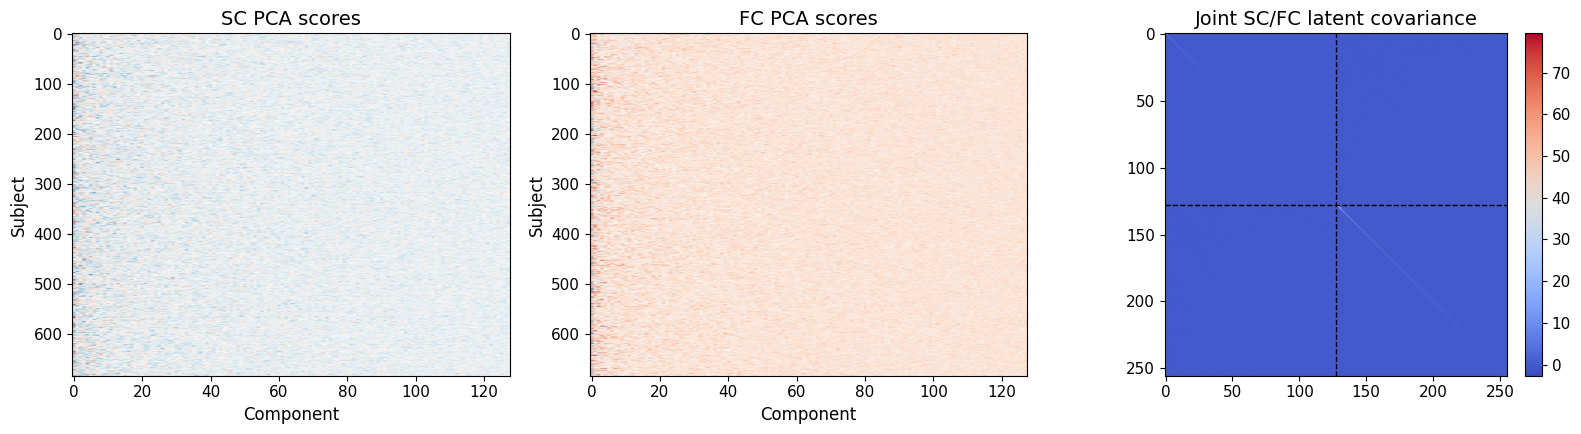

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
axes[0].imshow(sc_scores, aspect="auto", cmap="RdBu_r")
axes[0].set_title("SC PCA scores")
axes[0].set_xlabel("Component")
axes[0].set_ylabel("Subject")

axes[1].imshow(fc_scores, aspect="auto", cmap="RdBu_r")
axes[1].set_title("FC PCA scores")
axes[1].set_xlabel("Component")
axes[1].set_ylabel("Subject")

joint_cov = np.cov(np.concatenate([sc_scores, fc_scores], axis=1), rowvar=False)
im = axes[2].imshow(joint_cov, cmap="coolwarm")
axes[2].set_title("Joint SC/FC latent covariance")
axes[2].axvline(model_trained.n_components_pca - 0.5, color="k", linestyle="--", linewidth=1)
axes[2].axhline(model_trained.n_components_pca - 0.5, color="k", linestyle="--", linewidth=1)
plt.colorbar(im, ax=axes[2], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()


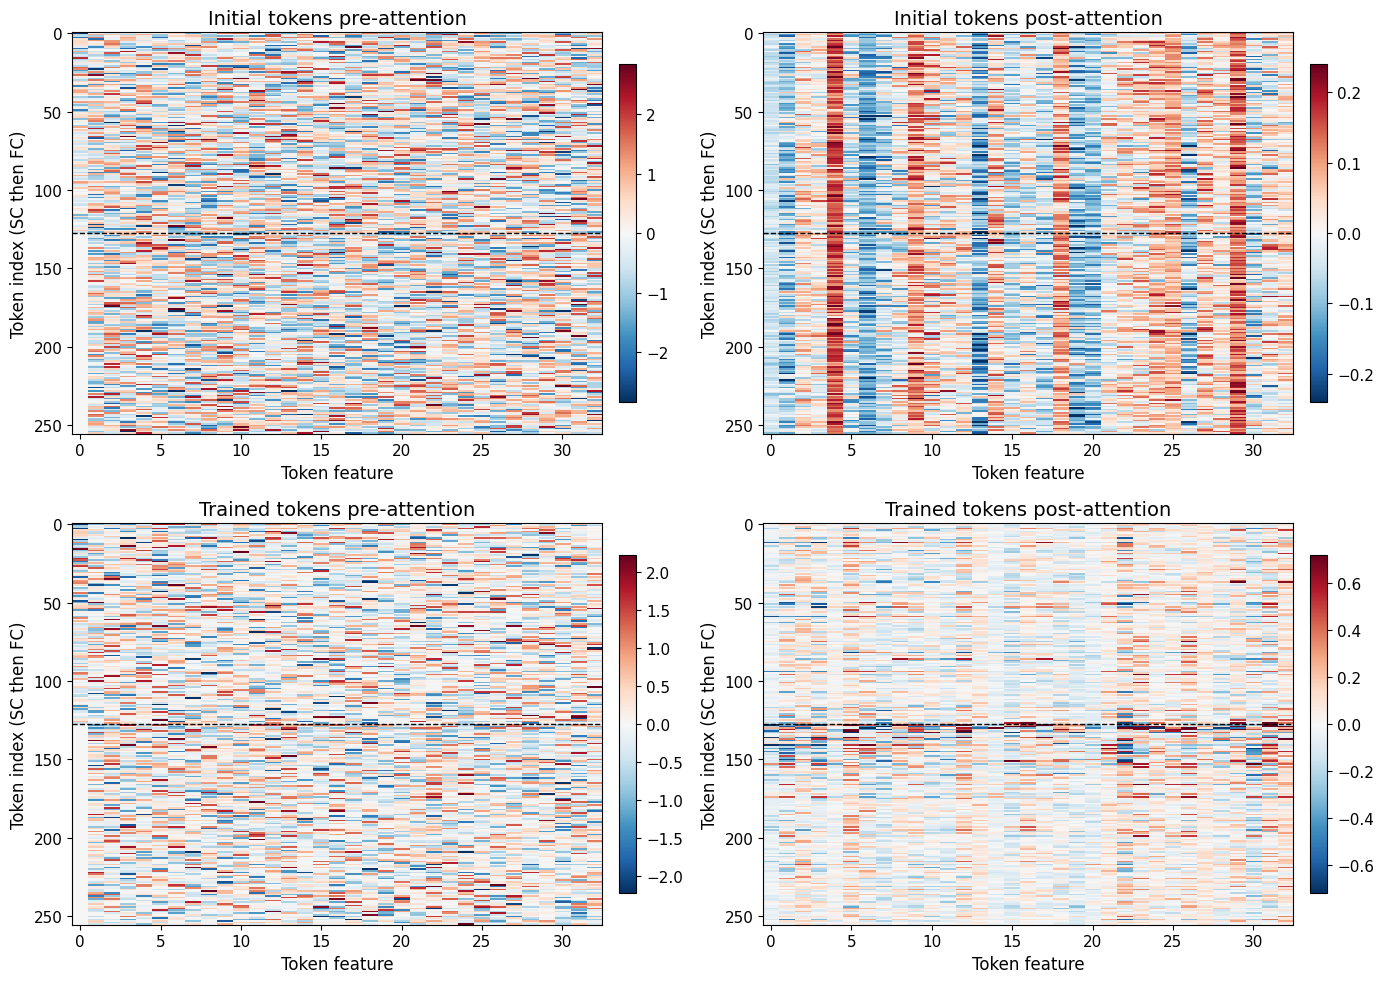

In [26]:
def show_tokens(title, tensor):
    arr = tensor.detach().cpu().squeeze(0).numpy()
    bound = np.quantile(np.abs(arr), 0.995) + 1e-8
    plt.imshow(
        arr,
        aspect="auto",
        cmap="RdBu_r",
        vmin=-bound,
        vmax=bound,
        interpolation="nearest",
    )
    plt.title(title)
    plt.xlabel("Token feature")
    plt.ylabel("Token index (SC then FC)")
    plt.axhline(model_trained.n_components_pca - 0.5, color="k", linestyle="--", linewidth=1)
    plt.colorbar(fraction=0.03, pad=0.03)


fig = plt.figure(figsize=(14, 10))
plt.subplot(2, 2, 1)
show_tokens("Initial tokens pre-attention", inspect_init["tokens_pre"])
plt.subplot(2, 2, 2)
show_tokens("Initial tokens post-attention", inspect_init["tokens_post"])
plt.subplot(2, 2, 3)
show_tokens("Trained tokens pre-attention", inspect_trained["tokens_pre"])
plt.subplot(2, 2, 4)
show_tokens("Trained tokens post-attention", inspect_trained["tokens_post"])
plt.tight_layout()
plt.show()


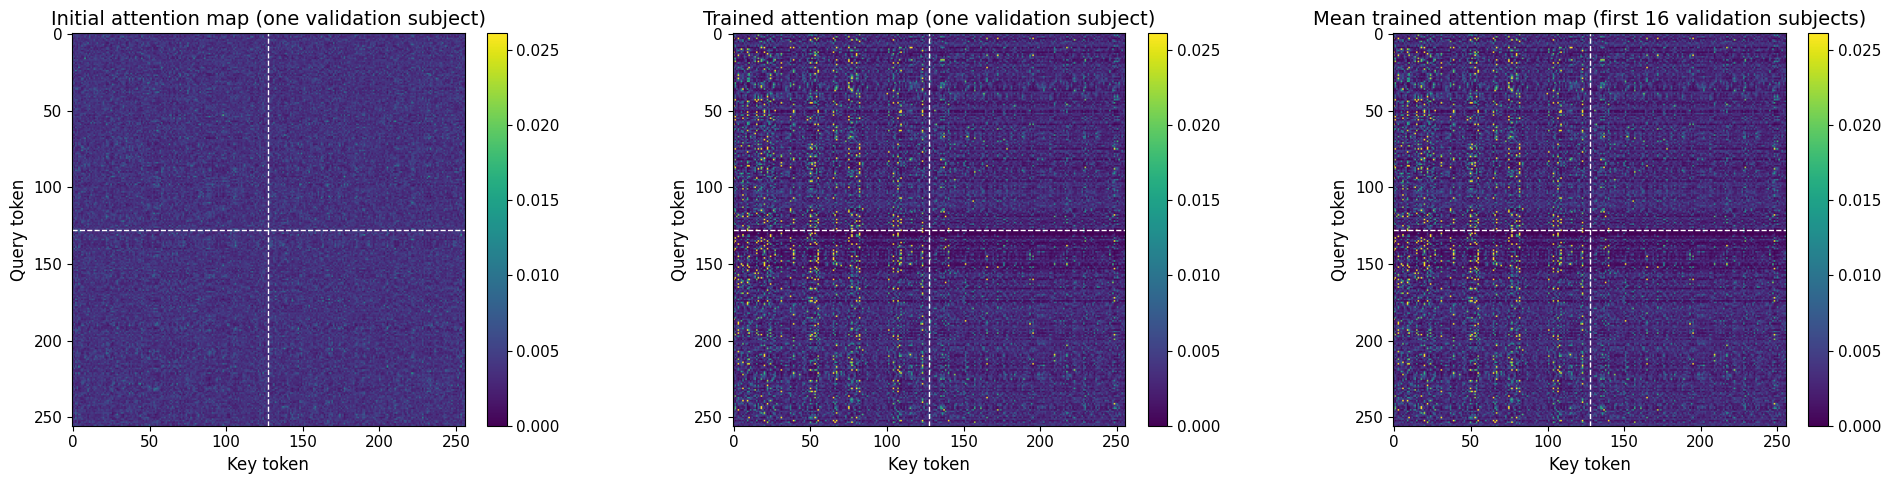

In [27]:
init_attn = inspect_init["attention"].detach().cpu()
trained_attn = inspect_trained["attention"].detach().cpu()
mean_attn = inspect_mean["attention"].detach().cpu()

def reduce_attention(attn, average_subjects=False):
    # old single-head: (B, T, T)
    # new multi-head: (B, H, T, T)
    if attn.ndim == 4:
        if average_subjects:
            return attn.mean(dim=(0, 1)).numpy()   # avg over subjects and heads
        return attn[0].mean(dim=0).numpy()         # first subject, avg over heads
    if average_subjects:
        return attn.mean(dim=0).numpy()            # avg over subjects
    return attn[0].numpy()                         # first subject

init_attn_mat = reduce_attention(init_attn, average_subjects=False)
trained_attn_mat = reduce_attention(trained_attn, average_subjects=False)
mean_attn_mat = reduce_attention(mean_attn, average_subjects=True)

all_vals = np.concatenate([
    init_attn_mat.ravel(),
    trained_attn_mat.ravel(),
    mean_attn_mat.ravel(),
])
vmax = np.quantile(all_vals, 0.995)

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
for ax, mat, title in [
    (axes[0], init_attn_mat, "Initial attention map (one validation subject)"),
    (axes[1], trained_attn_mat, "Trained attention map (one validation subject)"),
    (axes[2], mean_attn_mat, "Mean trained attention map (first 16 validation subjects)"),
]:
    im = ax.imshow(mat, cmap="viridis", vmin=0.0, vmax=vmax)
    ax.set_title(title)
    ax.set_xlabel("Key token")
    ax.set_ylabel("Query token")
    ax.axvline(model_trained.n_components_pca - 0.5, color="w", linestyle="--", linewidth=1)
    ax.axhline(model_trained.n_components_pca - 0.5, color="w", linestyle="--", linewidth=1)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()


## Math Summary

This notebook uses the non-Transformer `LatentAttnMasked` model with `readout_type="scalar_slot"`.

Let the SC latent coefficients be $c_s \in \mathbb{R}^k$ and the FC latent coefficients be $c_t \in \mathbb{R}^k$.
For each subject, component $i$ becomes a token by concatenating a scalar latent value with a learned component embedding:

$$
T^{pre}_{SC,i} = [c_{s,i}; e^{SC}_i], \qquad
T^{pre}_{FC,j} = [m_j; e^{FC}_j]
$$

where $m_j$ is either the visible FC latent value for that subject or the learned mask value if that FC component is masked.

This means the token plots in the notebook are subject-specific token matrices:

- `tokens_pre`: the token matrix before any token mixing.
- `tokens_post`: the token matrix after the attention update.

So the pre-token plots show the raw latent-value-plus-embedding representation, while the post-token plots show how those token features change after each token has mixed information from the others.

For the simple attention model, the pre-attention token matrix is

$$
T^{pre} = \begin{bmatrix} T^{pre}_{SC} \\ T^{pre}_{FC} \end{bmatrix}.
$$

The attention map is computed from the query and key projections of these tokens:

$$
Q = T^{pre} W_Q, \qquad K = T^{pre} W_K.
$$

The notebook's attention heatmaps visualize the pairwise token-token interaction matrix

$$
A = \phi\!\left(\frac{QK^\top}{\sqrt{d_a}}\right),
$$

where $\phi$ is either the identity map or the softmax, depending on the notebook.

The post-attention token matrix is then computed by mixing value vectors across tokens:

$$
T^{post} = AV.
$$

Because this notebook uses `scalar_slot`, the final FC latent prediction reads out the first feature channel of the FC token rows after attention:

$$
\hat c_t = T^{post}_{FC,:,0}.
$$

So in this scalar-slot setting, the FC rows of `tokens_post` are especially important: their first column is the actual latent prediction used by the model, and the remaining columns are contextual features produced by the attention update.



In [28]:
artifact_dir = RESULTS_ROOT / "latent_masked_attention_smax_overview"
artifact_dir.mkdir(parents=True, exist_ok=True)
report_base = artifact_dir / "eval_test"

test_eval = run_out["evaluators"]["test"]
report_metrics = test_eval.analyze_results(
    verbose=False,
    filepath=str(report_base),
    output_format="md",
    model_name="LatentAttnMasked_attention_simple_smax",
)

print(f"Markdown report saved to: {report_base}.md")
report_metrics["base_metrics"]


Number of unique demographic categories: 14
returned noise_preds [[ 0.10335521  0.27345122  0.79338547 ...  0.07845211  0.10779614
   0.35724186]
 [ 0.1919979   0.47149277  0.6724819  ... -0.13729251 -0.09331813
   0.66529665]
 [ 0.3631451   0.63926478  0.88444692 ... -0.01370378  0.1294217
   0.39960487]
 ...
 [-0.08238107  0.82869741  1.07752772 ... -0.06908563 -0.00440757
   0.40327927]
 [ 0.12395491  0.68586381  0.6269891  ... -0.12566293  0.16673286
   0.53747594]
 [ 0.05569953  0.62698837  0.69579952 ... -0.09271121  0.09947315
   0.36341394]]
Markdown report saved to: results/local_results/latent_masked_attention_smax_overview/eval_test.md
Figures saved to: results/local_results/latent_masked_attention_smax_overview/eval_test_plots/
Markdown report saved to: results/local_results/latent_masked_attention_smax_overview/eval_test.md


{'mse': np.float32(0.013344258),
 'r2': np.float32(-0.010007487),
 'pearson': np.float32(0.83878547),
 'demeaned_pearson': np.float32(0.025381831),
 'avg_rank': np.float64(0.5627613412228797),
 'top1_acc': np.float64(0.015384615384615385)}